# Bank Marketing — Complete EDA
### All 8 EDA Steps | Sequential Execution

In [3]:
# ── Common Imports & Setup ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Load Data ───────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\Administrator\Desktop\Machine Learning Engineer\bank+marketing\bank-full.csv", sep=";")

df.rename(columns={
    'default': 'credit_default', 'balance': 'avg_annual_bal',
    'housing': 'housing_loan',   'loan': 'personal_loan',
    'contact': 'contact_type',   'month': 'contact_month',
    'campaign': 'curr_campaign', 'pdays': 'passed_days',
    'previous': 'prev_campaign', 'poutcome': 'prev_outcome'
}, inplace=True)

# Binary encode target for numeric use
df['y_bin'] = (df['y'] == 'yes').astype(int)

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")

Dataset shape : (45211, 18)
Columns       : ['age', 'job', 'marital', 'education', 'credit_default', 'avg_annual_bal', 'housing_loan', 'personal_loan', 'contact_type', 'day', 'contact_month', 'duration', 'curr_campaign', 'passed_days', 'prev_campaign', 'prev_outcome', 'y', 'y_bin']


---
## EDA 1 — Target Variable Distribution (Class Imbalance Analysis)

 TARGET VARIABLE DISTRIBUTION
  Subscribed (yes) :  5,289  (11.70%)
  Not subscribed   : 39,922  (88.30%)
  Imbalance ratio  : 7.5 : 1  (no : yes)


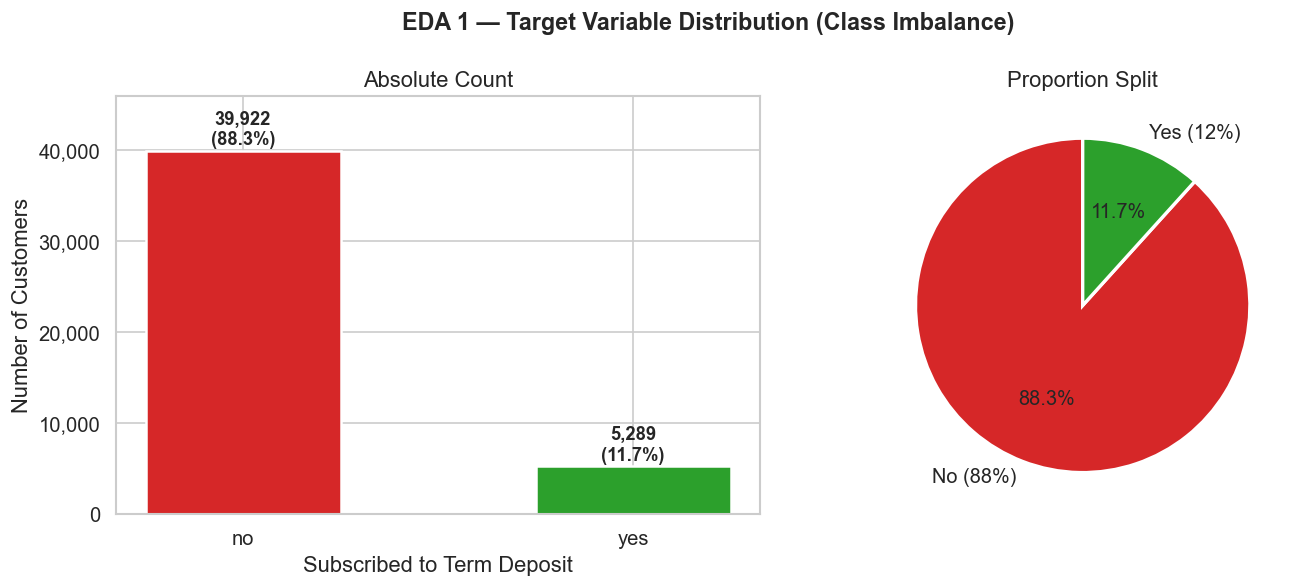


⚠️  Imbalance Implication: With an ~8:1 ratio, accuracy is a misleading metric.
    Use ROC-AUC, F1, Precision-Recall. Consider SMOTE or class_weight='balanced'.


In [13]:
# ── EDA 1: Target Variable Distribution ────────────────────────────────────
counts   = df['y'].value_counts()
pct      = df['y'].value_counts(normalize=True) * 100
imb_ratio = counts['no'] / counts['yes']

print("=" * 45)
print(" TARGET VARIABLE DISTRIBUTION")
print("=" * 45)
print(f"  Subscribed (yes) : {counts['yes']:>6,}  ({pct['yes']:.2f}%)")
print(f"  Not subscribed   : {counts['no']:>6,}  ({pct['no']:.2f}%)")
print(f"  Imbalance ratio  : {imb_ratio:.1f} : 1  (no : yes)")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('EDA 1 — Target Variable Distribution (Class Imbalance)', fontsize=14, fontweight='bold')

# Bar chart
colors = ['#d62728', '#2ca02c']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xlabel('Subscribed to Term Deposit')
for bar, val, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({p:.1f}%)', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(counts.values, labels=['No (88%)', 'Yes (12%)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Proportion Split')

plt.tight_layout()
plt.show()

print("\n⚠️  Imbalance Implication: With an ~8:1 ratio, accuracy is a misleading metric.")
print("    Use ROC-AUC, F1, Precision-Recall. Consider SMOTE or class_weight='balanced'.")

---
## EDA 2 — `passed_days` Special Value (-1) Segmentation

 passed_days SEGMENTATION (-1 = Never Contacted Before)
  Never Contacted       : 36,954 rows  |  Subscription Rate: 9.16%
  Previously Contacted  :  8,257 rows  |  Subscription Rate: 23.07%


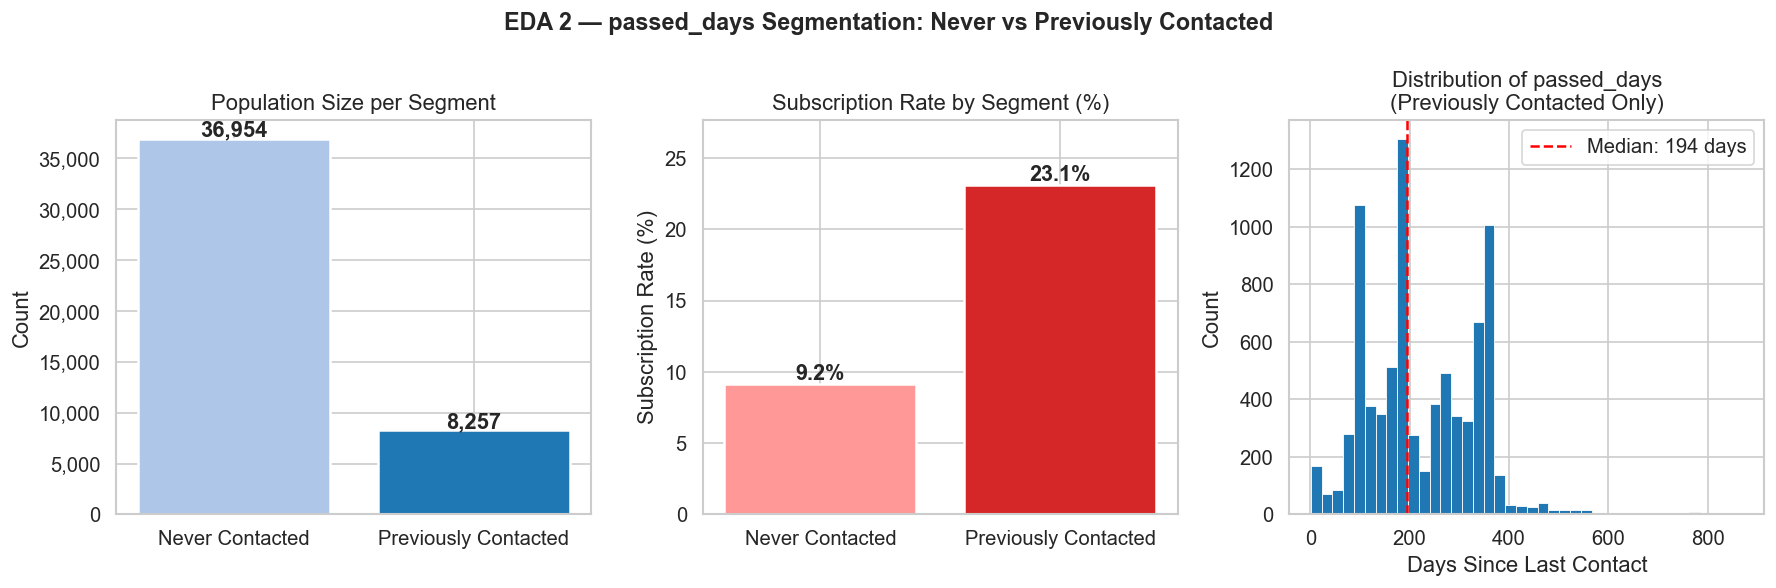


📌 Key Insight: If previously contacted customers have a significantly higher
    subscription rate, passed_days is a strong segmentation signal.


In [5]:
# ── EDA 2: passed_days = -1 Segmentation ───────────────────────────────────
df['contacted_before'] = df['passed_days'].apply(lambda x: 'Never Contacted' if x == -1 else 'Previously Contacted')

seg_counts  = df['contacted_before'].value_counts()
seg_sub     = df.groupby('contacted_before')['y_bin'].mean() * 100

print("=" * 55)
print(" passed_days SEGMENTATION (-1 = Never Contacted Before)")
print("=" * 55)
for seg in seg_counts.index:
    print(f"  {seg:<22}: {seg_counts[seg]:>6,} rows  |  Subscription Rate: {seg_sub[seg]:.2f}%")
print("=" * 55)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('EDA 2 — passed_days Segmentation: Never vs Previously Contacted', fontsize=14, fontweight='bold')

seg_colors = ['#aec7e8', '#1f77b4']

# Population split
axes[0].bar(seg_counts.index, seg_counts.values, color=seg_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Population Size per Segment')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(seg_counts.items()):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Subscription rate comparison
bars = axes[1].bar(seg_sub.index, seg_sub.values, color=['#ff9896', '#d62728'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Subscription Rate by Segment (%)')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].set_ylim(0, seg_sub.max() * 1.2)
for bar, val in zip(bars, seg_sub.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)

# Distribution of passed_days (excluding -1)
prev_contacted = df[df['passed_days'] != -1]['passed_days']
axes[2].hist(prev_contacted, bins=40, color='#1f77b4', edgecolor='white', linewidth=0.5)
axes[2].set_title('Distribution of passed_days\n(Previously Contacted Only)')
axes[2].set_xlabel('Days Since Last Contact')
axes[2].set_ylabel('Count')
axes[2].axvline(prev_contacted.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {prev_contacted.median():.0f} days')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n📌 Key Insight: If previously contacted customers have a significantly higher")
print("    subscription rate, passed_days is a strong segmentation signal.")

---
## EDA 3 — Subscription Rate by Category (Group-wise Analysis)

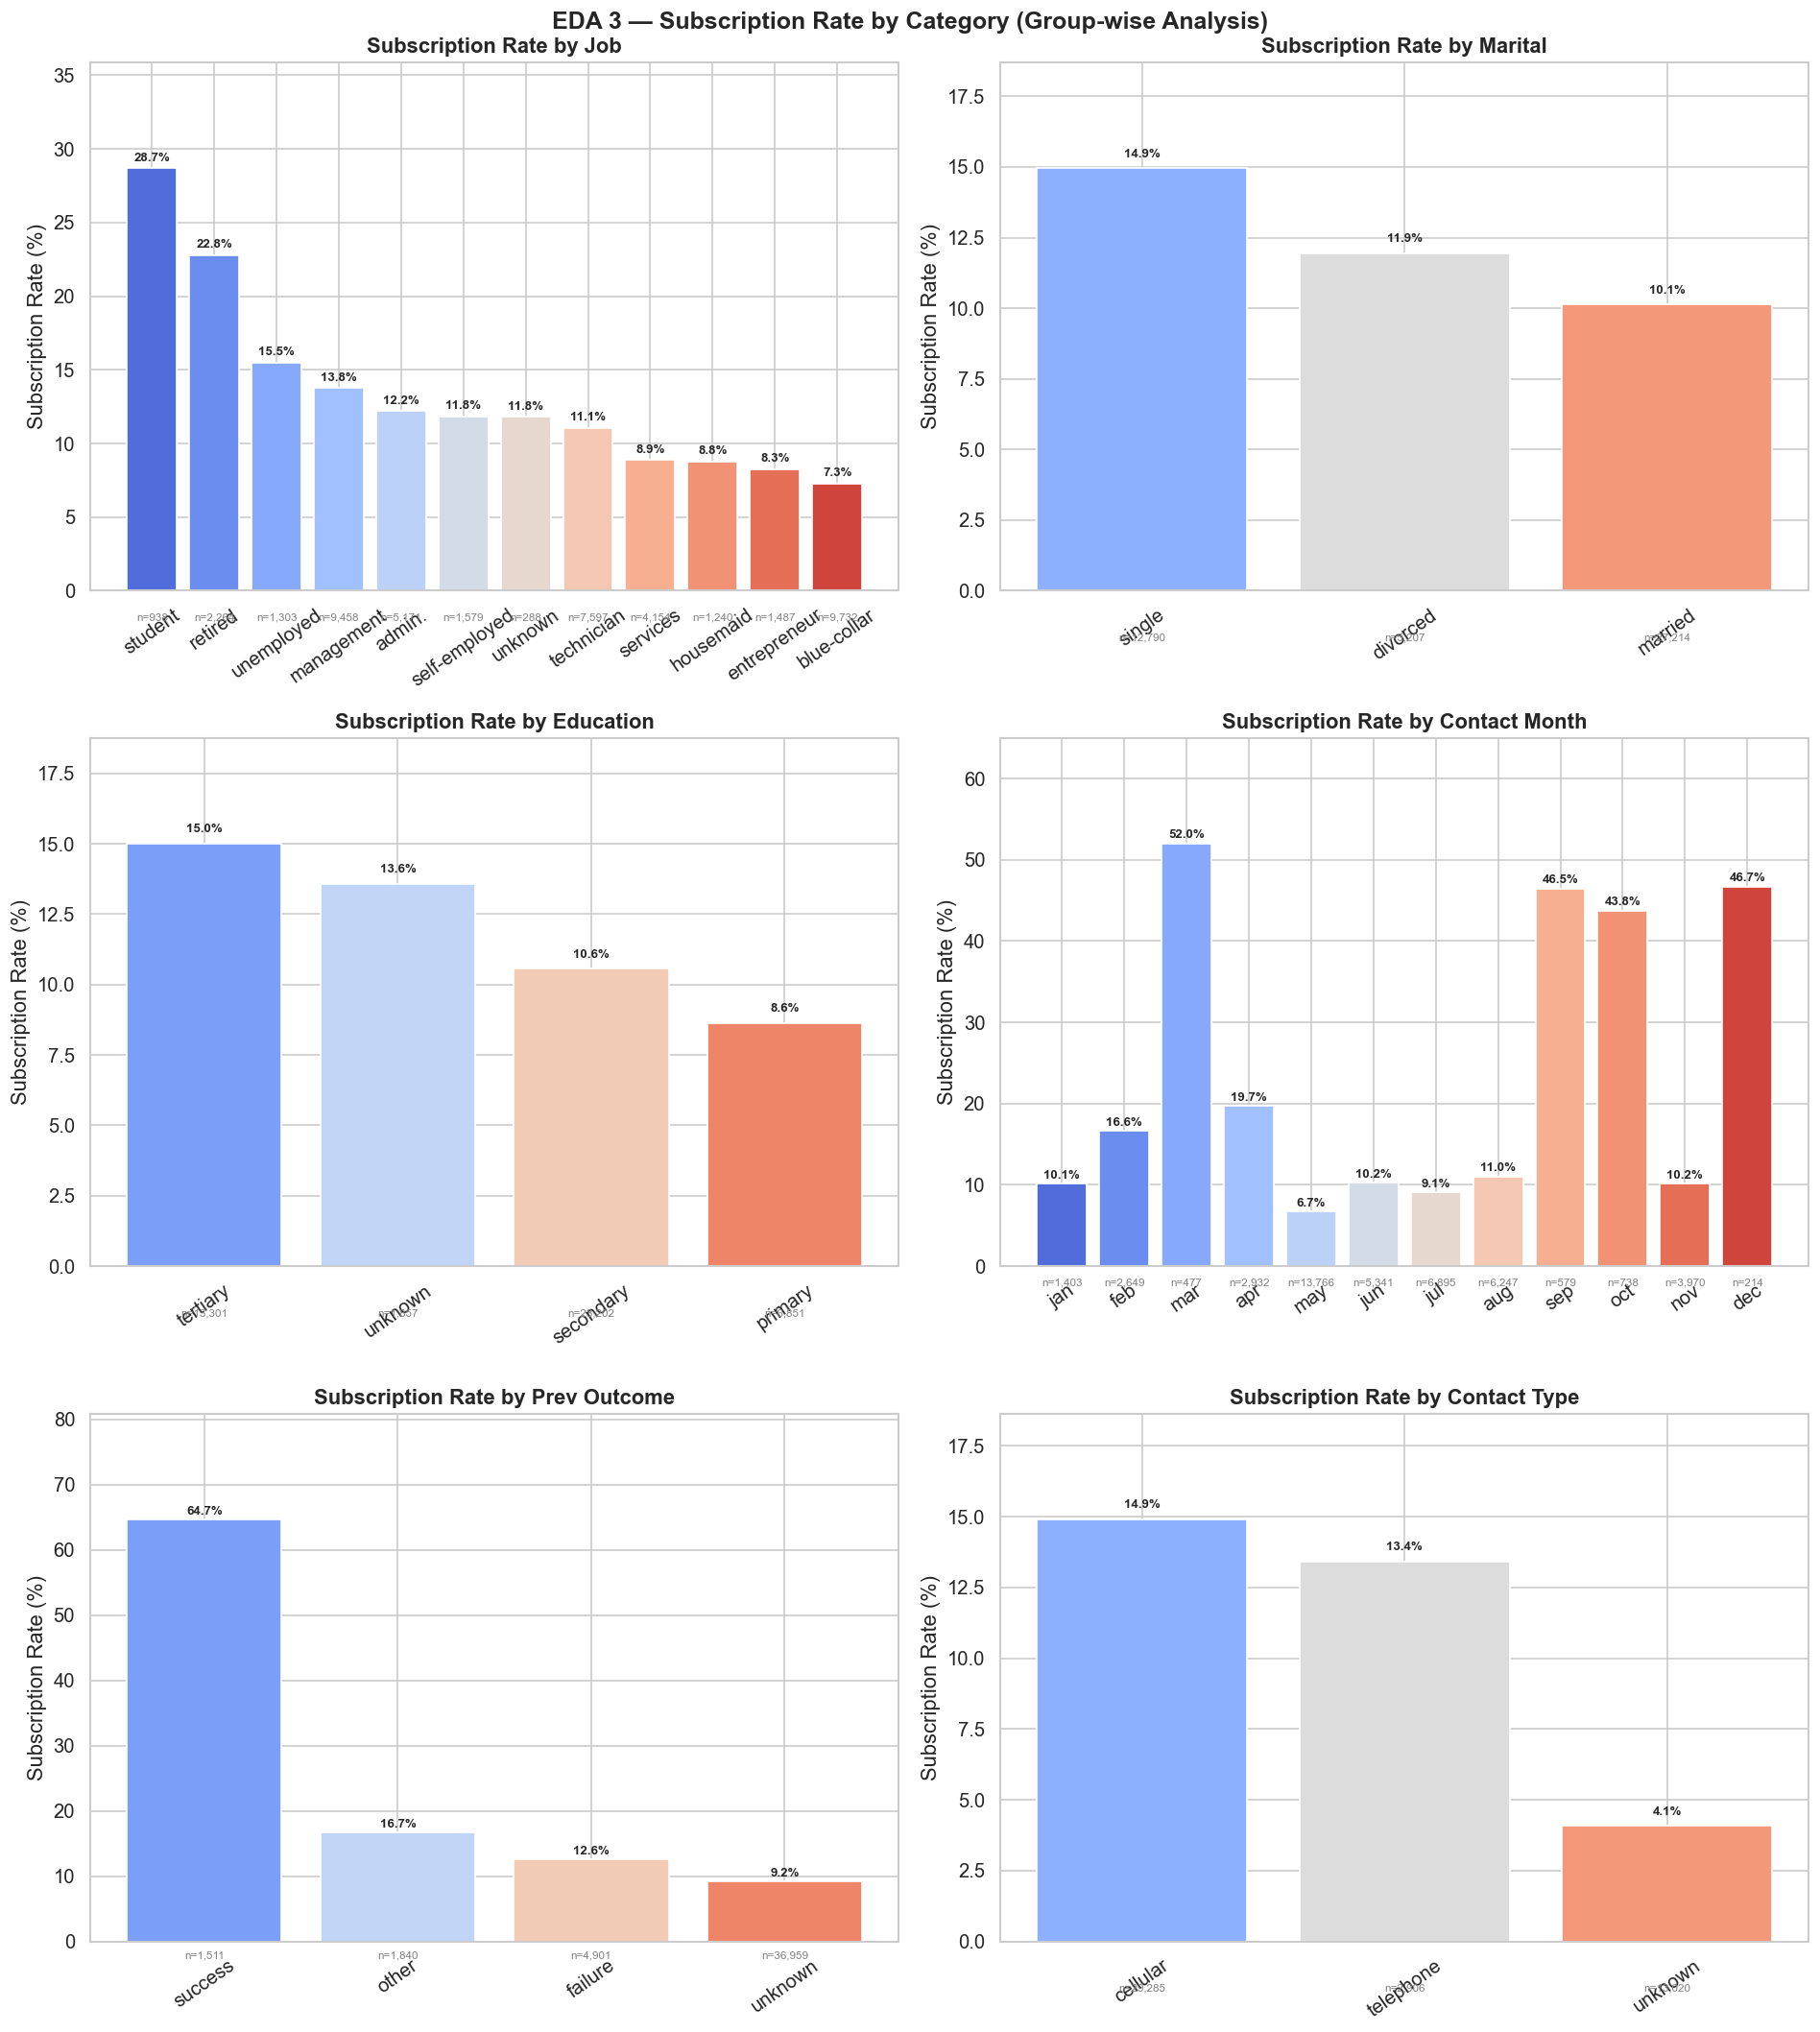


── Subscription Rate Rankings ──

JOB
          job  Sub Rate (%)
      student         28.68
      retired         22.79
   unemployed         15.50
   management         13.76
       admin.         12.20
self-employed         11.84
      unknown         11.81
   technician         11.06
     services          8.88
    housemaid          8.79
 entrepreneur          8.27
  blue-collar          7.27

MARITAL
 marital  Sub Rate (%)
  single         14.95
divorced         11.95
 married         10.12

EDUCATION
education  Sub Rate (%)
 tertiary         15.01
  unknown         13.57
secondary         10.56
  primary          8.63

CONTACT_MONTH
contact_month  Sub Rate (%)
          mar         51.99
          dec         46.73
          sep         46.46
          oct         43.77
          apr         19.68
          feb         16.65
          aug         11.01
          jun         10.22
          nov         10.15
          jan         10.12
          jul          9.09
          may 

In [6]:
# ── EDA 3: Subscription Rate by Category ───────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'contact_month', 'prev_outcome', 'contact_type']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('EDA 3 — Subscription Rate by Category (Group-wise Analysis)', fontsize=15, fontweight='bold')
axes = axes.flatten()

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

for i, col in enumerate(cat_cols):
    sub_rate  = df.groupby(col)['y_bin'].mean() * 100
    sub_count = df.groupby(col)['y_bin'].count()

    if col == 'contact_month':
        existing = [m for m in month_order if m in sub_rate.index]
        sub_rate  = sub_rate.reindex(existing)
        sub_count = sub_count.reindex(existing)
    else:
        sub_rate  = sub_rate.sort_values(ascending=False)
        sub_count = sub_count.reindex(sub_rate.index)

    palette = sns.color_palette('coolwarm', len(sub_rate))
    bars = axes[i].bar(sub_rate.index, sub_rate.values,
                       color=palette, edgecolor='white', linewidth=1)
    axes[i].set_title(f'Subscription Rate by {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel('Subscription Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].set_ylim(0, sub_rate.max() * 1.25)

    # Annotate bars with rate and count
    for bar, rate, cnt in zip(bars, sub_rate.values, sub_count.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{rate:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
        axes[i].text(bar.get_x() + bar.get_width()/2, -1.5,
                     f'n={cnt:,}', ha='center', va='top', fontsize=7, color='gray')

plt.tight_layout()
plt.show()

# Print ranked tables
print("\n── Subscription Rate Rankings ──")
for col in cat_cols:
    ranked = (df.groupby(col)['y_bin'].mean() * 100).sort_values(ascending=False).reset_index()
    ranked.columns = [col, 'Sub Rate (%)']
    ranked['Sub Rate (%)'] = ranked['Sub Rate (%)'].round(2)
    print(f"\n{col.upper()}")
    print(ranked.to_string(index=False))

---
## EDA 4 — Bivariate Analysis: Top Features vs Target

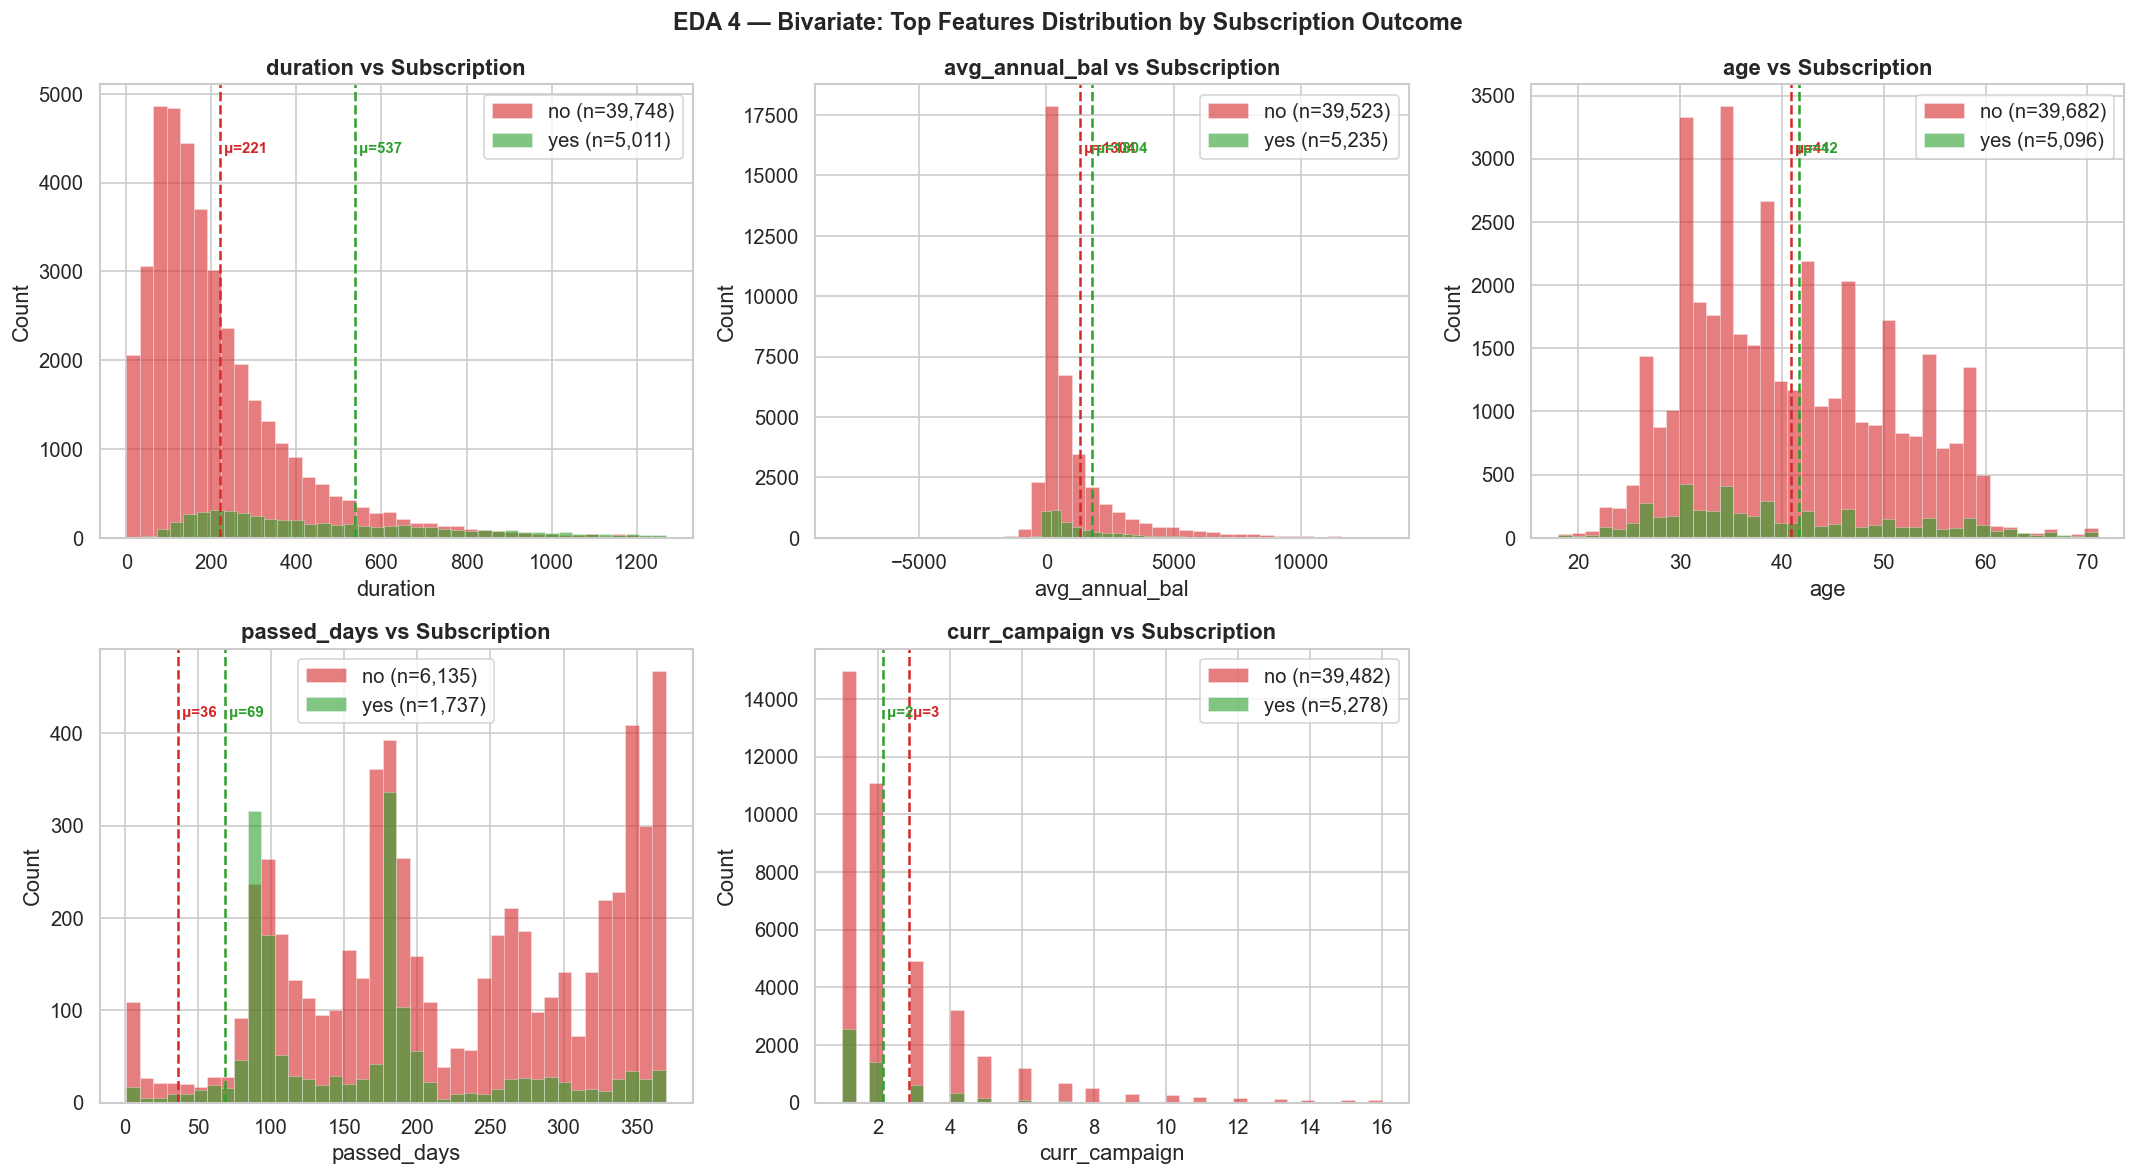


── Mean Value Comparison: Subscribers vs Non-Subscribers ──
y                    no      yes  Difference (yes - no) % Difference
duration         221.18   537.29                 316.11       142.9%
avg_annual_bal  1303.71  1804.27                 500.56        38.4%
age               40.84    41.67                   0.83         2.0%
passed_days       36.42    68.70                  32.28        88.6%
curr_campaign      2.85     2.14                  -0.71       -24.9%


In [7]:
# ── EDA 4: Bivariate — Top Numeric Features vs Target ──────────────────────
top_numeric = ['duration', 'avg_annual_bal', 'age', 'passed_days', 'curr_campaign']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA 4 — Bivariate: Top Features Distribution by Subscription Outcome', fontsize=14, fontweight='bold')
axes = axes.flatten()

palette = {'no': '#d62728', 'yes': '#2ca02c'}

for i, col in enumerate(top_numeric):
    # Cap extreme outliers for visual clarity
    p99 = df[col].quantile(0.99)
    plot_data = df[df[col] <= p99].copy()
    if col == 'passed_days':
        plot_data = plot_data[plot_data[col] != -1]

    for outcome, color in palette.items():
        subset = plot_data[plot_data['y'] == outcome][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label=f'{outcome} (n={len(subset):,})', edgecolor='white', linewidth=0.3)

    axes[i].set_title(f'{col} vs Subscription', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

    # Annotate means
    for outcome, color in palette.items():
        mean_val = df[df['y'] == outcome][col].mean()
        axes[i].axvline(mean_val, color=color, linestyle='--', linewidth=1.5)
        axes[i].text(mean_val, axes[i].get_ylim()[1] * 0.85,
                     f' μ={mean_val:.0f}', color=color, fontsize=9, fontweight='bold')

# Remove unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

# Mean comparison table
print("\n── Mean Value Comparison: Subscribers vs Non-Subscribers ──")
summary = df.groupby('y')[top_numeric].mean().T.round(2)
summary['Difference (yes - no)'] = (summary['yes'] - summary['no']).round(2)
summary['% Difference'] = ((summary['yes'] - summary['no']) / summary['no'] * 100).round(1).astype(str) + '%'
print(summary.to_string())

---
## EDA 5 — Outlier Analysis

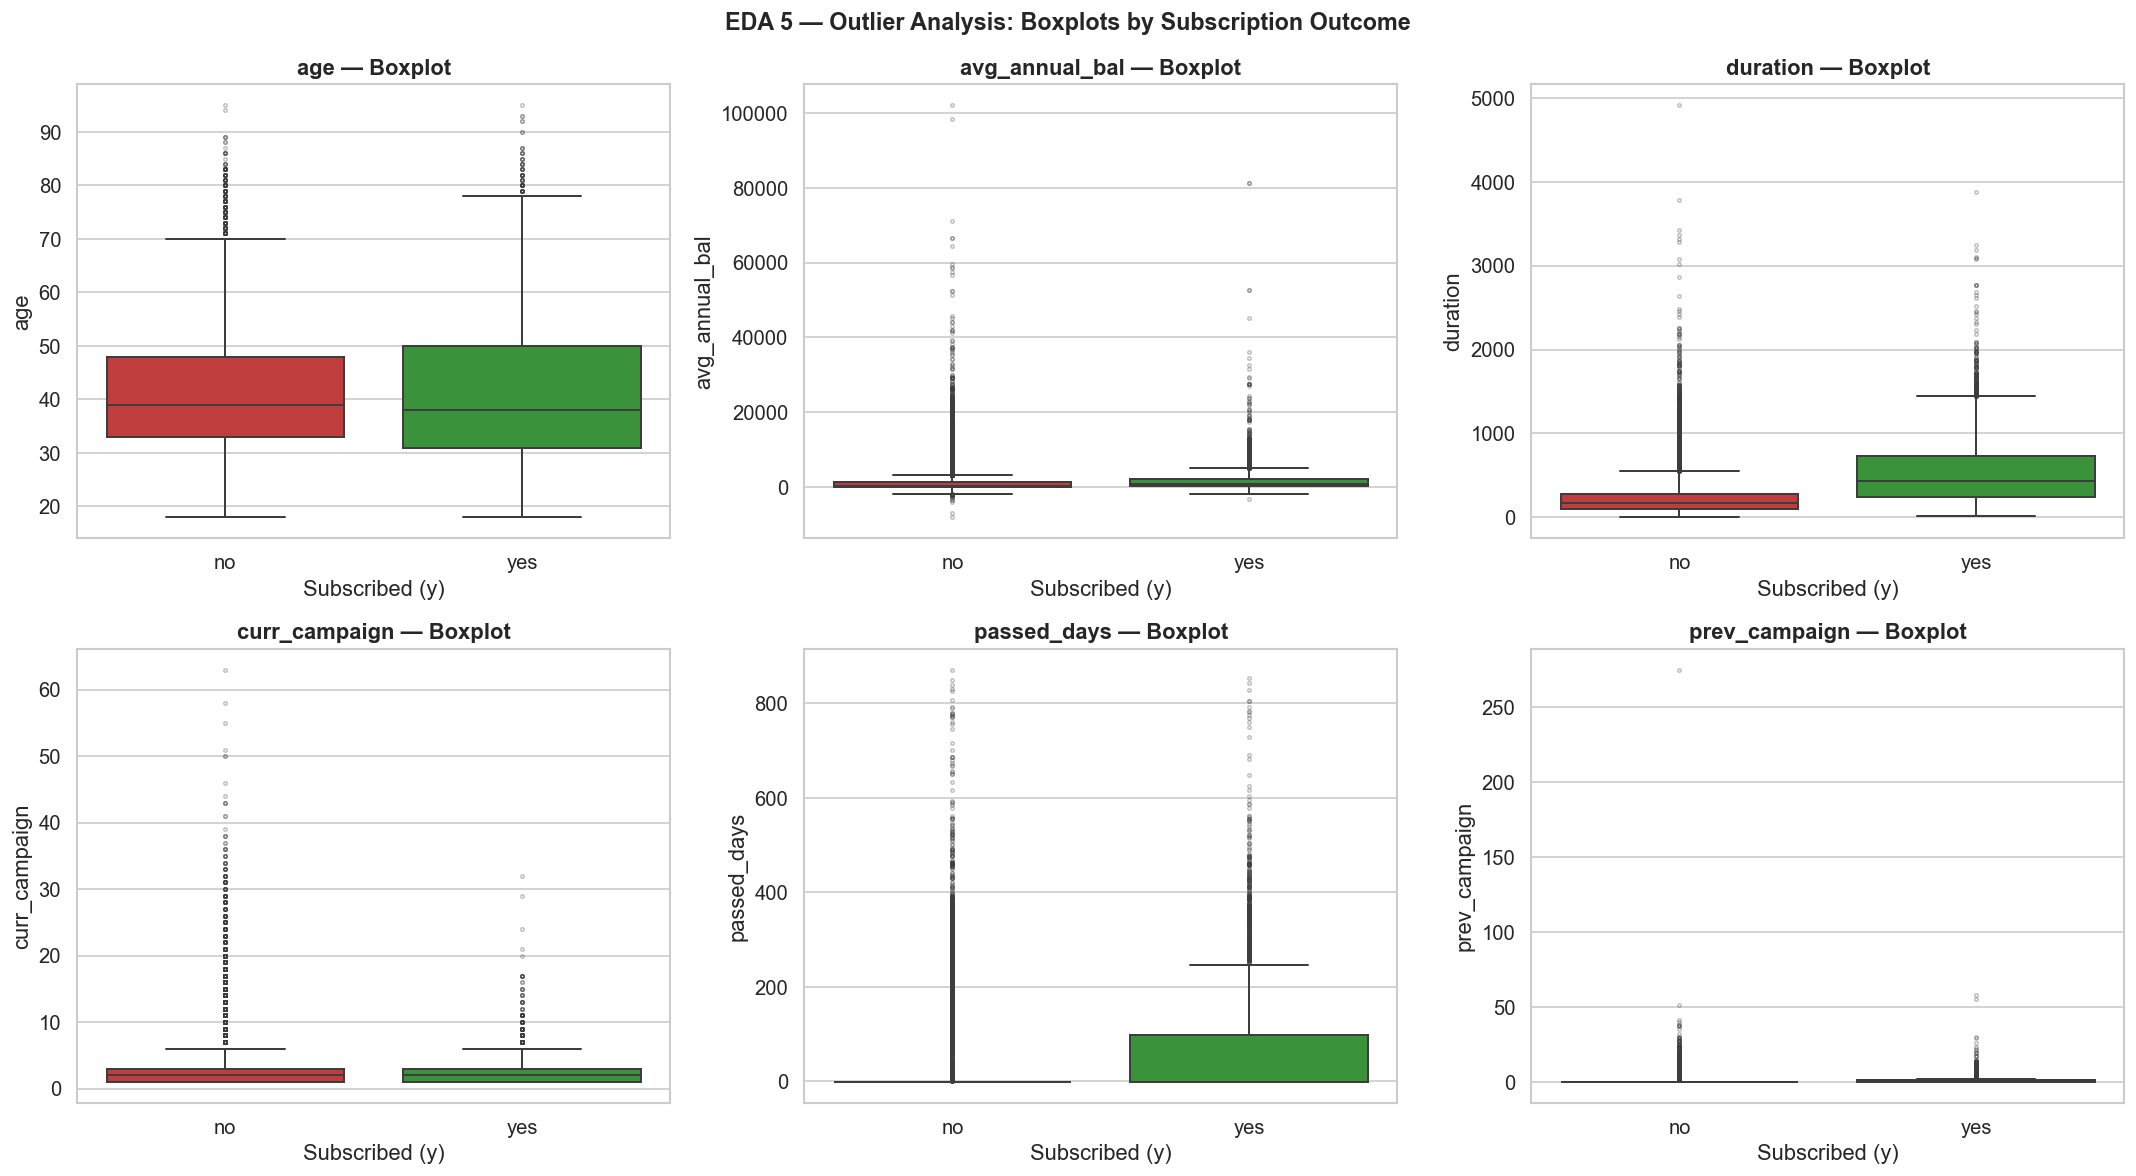


── IQR-Based Outlier Detection ──
Feature                      Q1         Q3        IQR        Lower        Upper   Outlier Count  Outlier %
---------------------------------------------------------------------------------------------------------
age                        33.0       48.0       15.0         10.5         70.5             487      1.08%
avg_annual_bal             72.0     1428.0     1356.0      -1962.0       3462.0           4,729     10.46%
duration                  103.0      319.0      216.0       -221.0        643.0           3,235      7.16%
curr_campaign               1.0        3.0        2.0         -2.0          6.0           3,064      6.78%
passed_days                -1.0       -1.0        0.0         -1.0         -1.0           8,257     18.26%
prev_campaign               0.0        0.0        0.0          0.0          0.0           8,257     18.26%

⚠️  Features with high outlier % require log-transform or capping before modelling.


In [8]:
# ── EDA 5: Outlier Analysis ─────────────────────────────────────────────────
numeric_cols = ['age', 'avg_annual_bal', 'duration', 'curr_campaign', 'passed_days', 'prev_campaign']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA 5 — Outlier Analysis: Boxplots by Subscription Outcome', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='y', y=col, palette={'no': '#d62728', 'yes': '#2ca02c'},
                ax=axes[i], linewidth=1.2, flierprops=dict(marker='o', markersize=2, alpha=0.3))
    axes[i].set_title(f'{col} — Boxplot', fontweight='bold')
    axes[i].set_xlabel('Subscribed (y)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# IQR-based outlier count table
print("\n── IQR-Based Outlier Detection ──")
print(f"{'Feature':<20} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>12} {'Upper':>12} {'Outlier Count':>15} {'Outlier %':>10}")
print("-" * 105)
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_out = n_out / len(df) * 100
    print(f"{col:<20} {Q1:>10.1f} {Q3:>10.1f} {IQR:>10.1f} {lower:>12.1f} {upper:>12.1f} {n_out:>15,} {pct_out:>9.2f}%")

print("\n⚠️  Features with high outlier % require log-transform or capping before modelling.")

---
## EDA 6 — Feature-to-Feature Correlation Heatmap

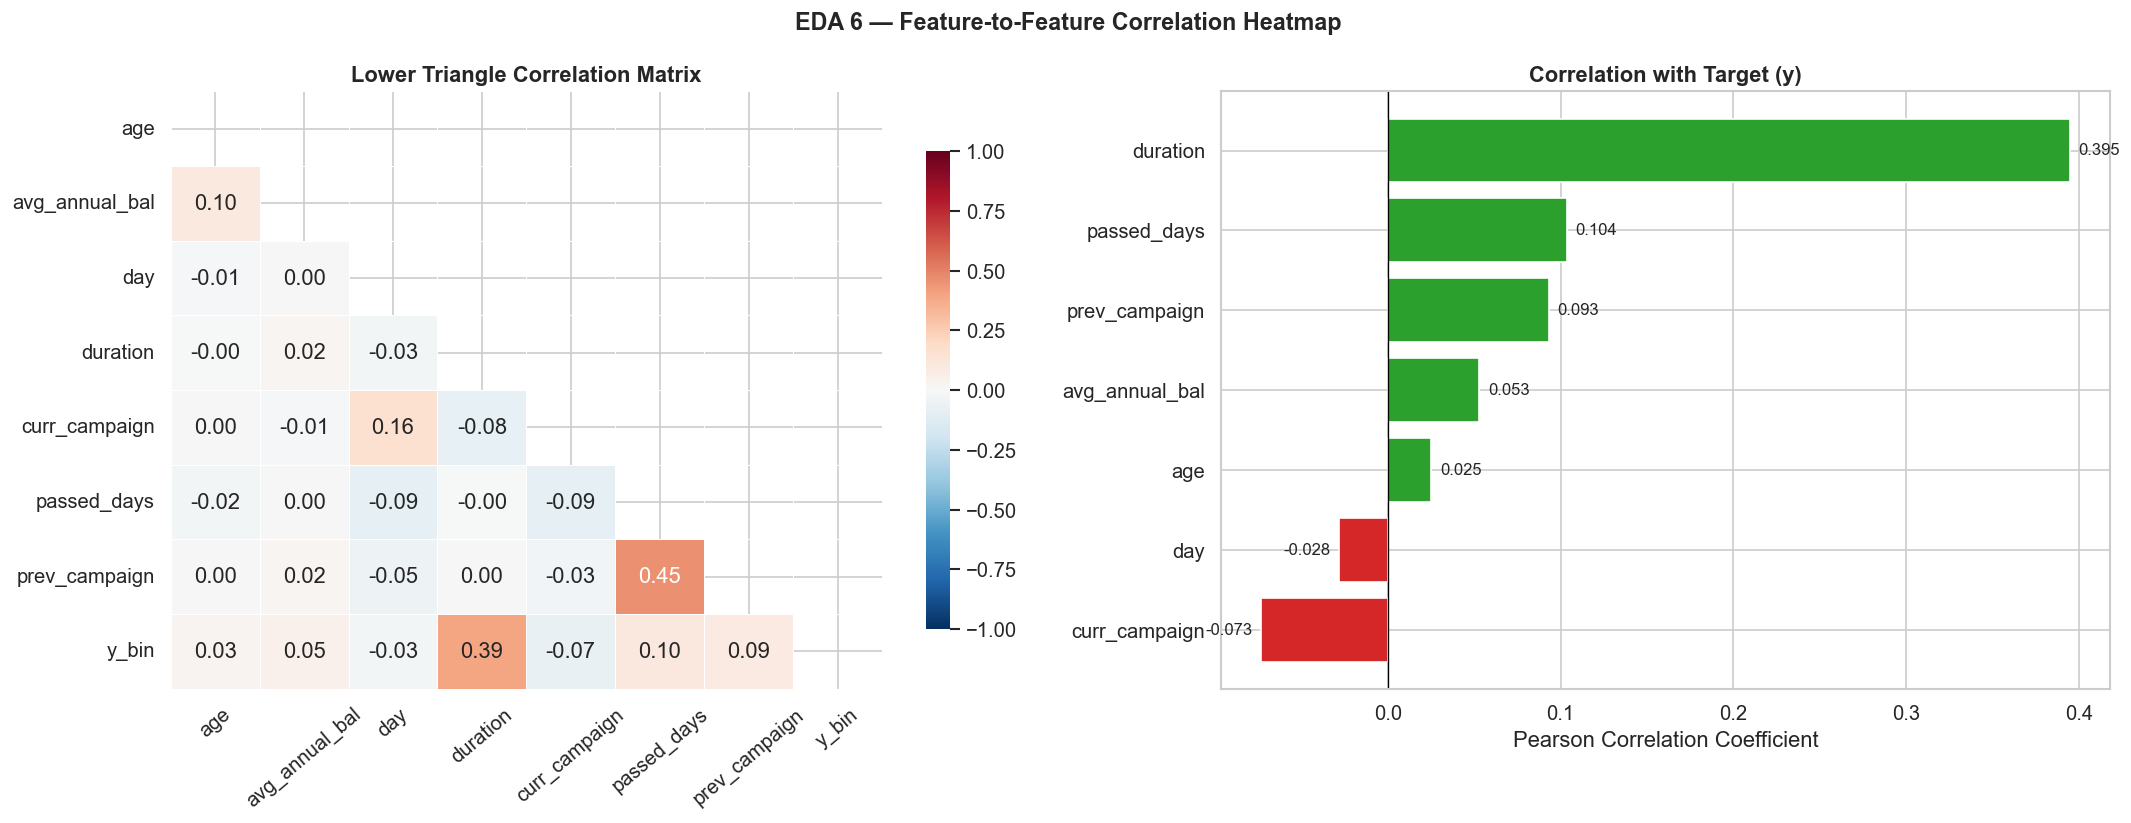


── High Inter-Feature Correlations (|r| > 0.3, excluding target) ──
Feature A            Feature B             Correlation
-------------------------------------------------------
passed_days          prev_campaign               0.455


In [9]:
# ── EDA 6: Feature-to-Feature Correlation Heatmap ──────────────────────────
numeric_cols_all = ['age', 'avg_annual_bal', 'day', 'duration',
                    'curr_campaign', 'passed_days', 'prev_campaign', 'y_bin']

corr_matrix = df[numeric_cols_all].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('EDA 6 — Feature-to-Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Lower Triangle Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)

# Correlation with target only — sorted bar chart
target_corr = corr_matrix['y_bin'].drop('y_bin').sort_values()
colors = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', linewidth=1)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Target (y)', fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
for i, (val, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

# Flag high inter-feature correlations
print("\n── High Inter-Feature Correlations (|r| > 0.3, excluding target) ──")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col_a = corr_matrix.columns[i]
        col_b = corr_matrix.columns[j]
        if col_a == 'y_bin' or col_b == 'y_bin':
            continue
        r = corr_matrix.loc[col_a, col_b]
        if abs(r) > 0.3:
            high_corr.append((col_a, col_b, round(r, 3)))

if high_corr:
    print(f"{'Feature A':<20} {'Feature B':<20} {'Correlation':>12}")
    print("-" * 55)
    for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{a:<20} {b:<20} {r:>12.3f}")
else:
    print("  No feature pairs with |r| > 0.3 found among numeric features.")

---
## EDA 7 — Campaign Contact Distribution Analysis

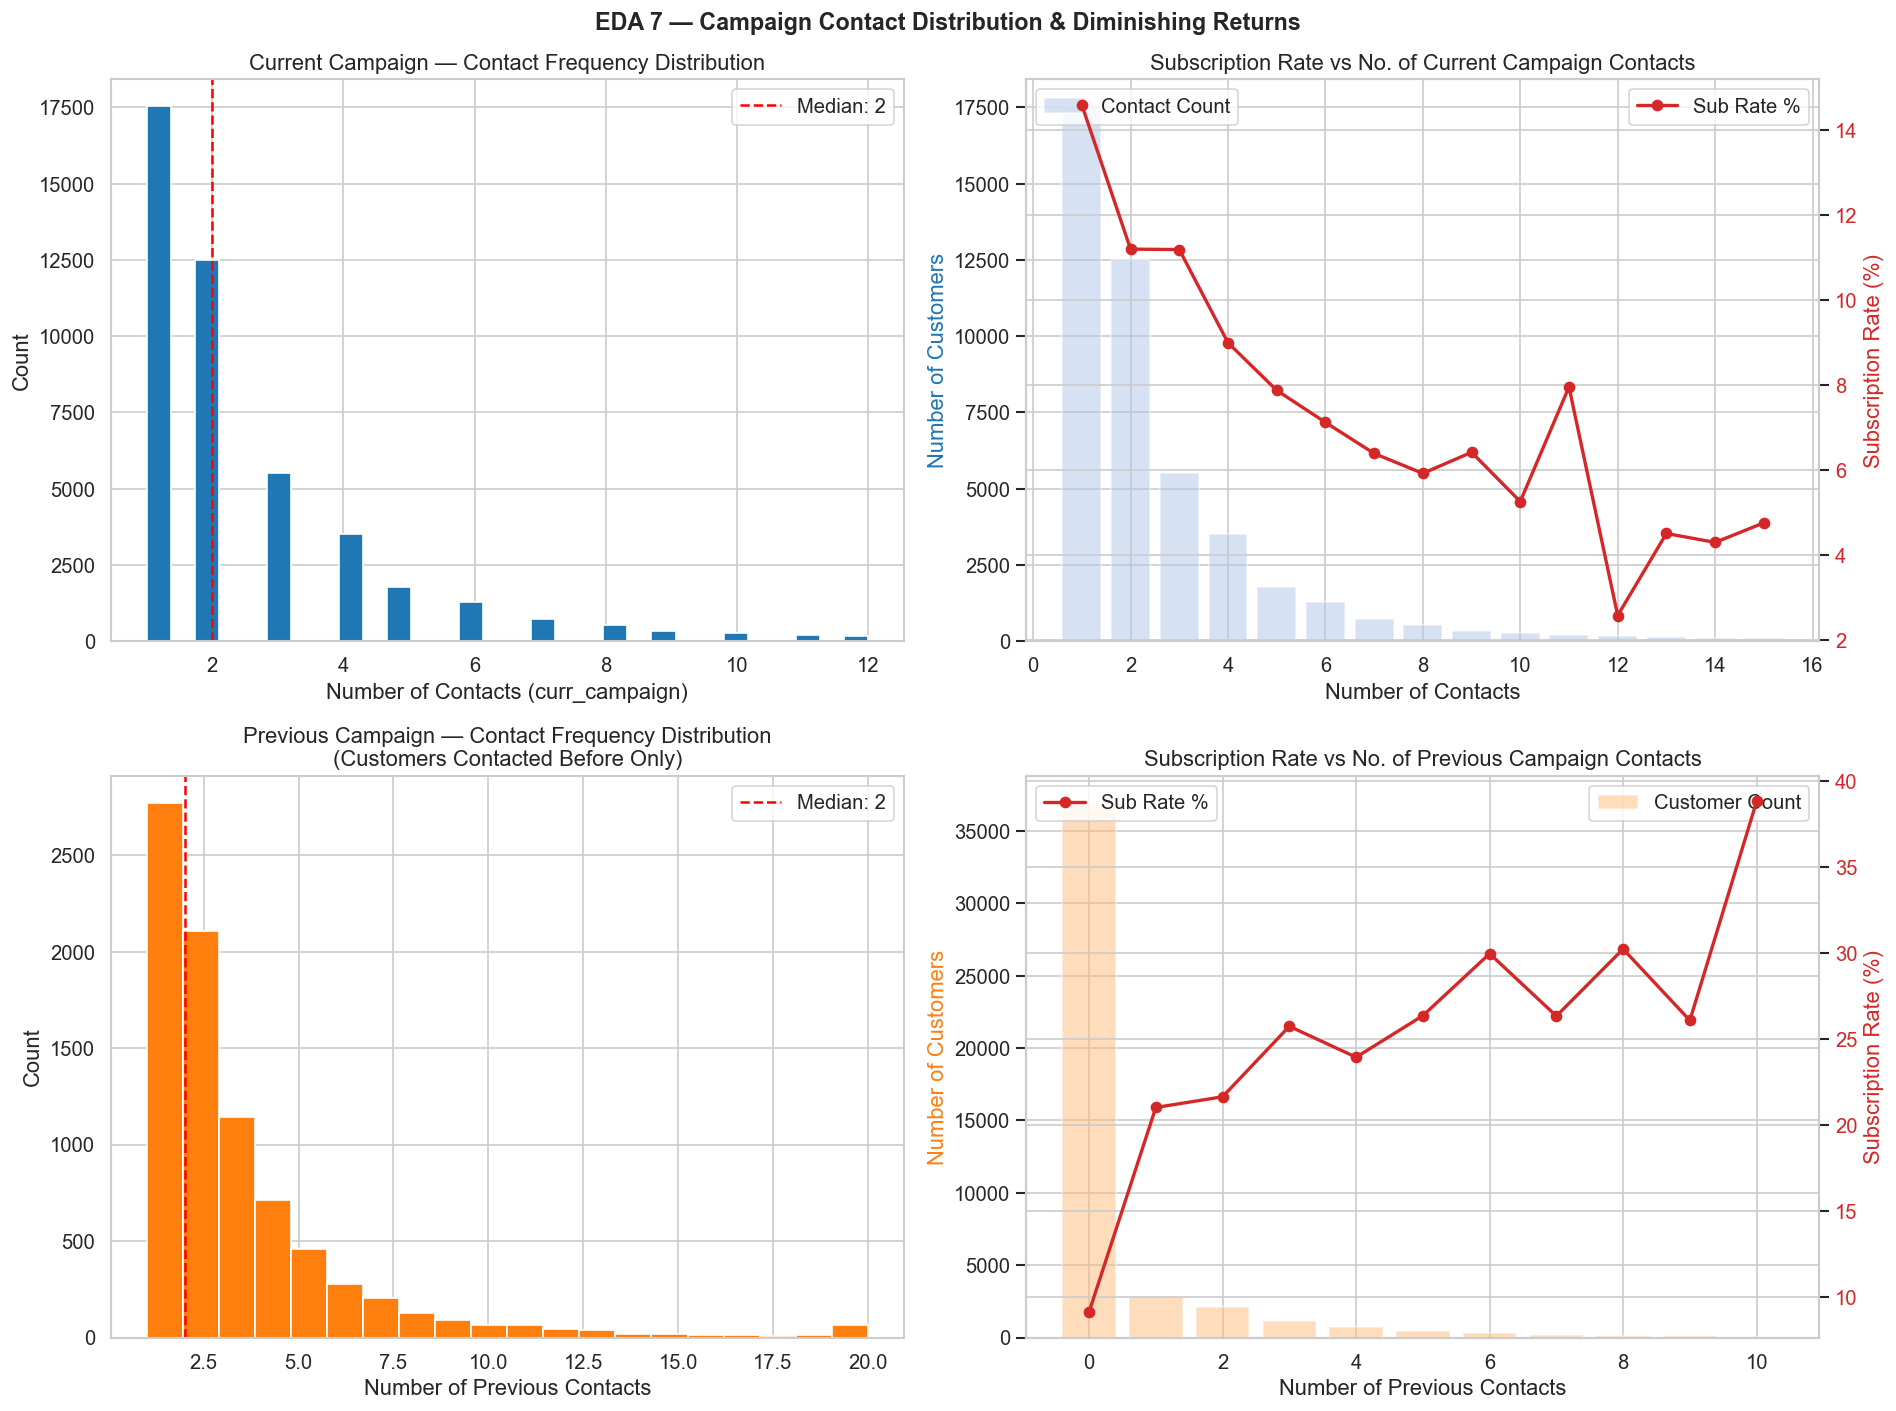


── Subscription Rate by No. of Current Campaign Contacts (first 10) ──
  Contacts  Subscription Rate   Customer Count
------------------------------------------------
         1             14.60%           17,544
         2             11.20%           12,505
         3             11.19%            5,521
         4              9.00%            3,522
         5              7.88%            1,764
         6              7.13%            1,291
         7              6.39%              735
         8              5.93%              540
         9              6.42%              327
        10              5.26%              266


In [10]:
# ── EDA 7: Campaign Contact Distribution Analysis ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EDA 7 — Campaign Contact Distribution & Diminishing Returns', fontsize=14, fontweight='bold')

# --- Plot 1: curr_campaign distribution ---
cap = df['curr_campaign'].quantile(0.98)
curr_cap = df[df['curr_campaign'] <= cap]
axes[0,0].hist(curr_cap['curr_campaign'], bins=30, color='#1f77b4', edgecolor='white')
axes[0,0].set_title('Current Campaign — Contact Frequency Distribution')
axes[0,0].set_xlabel('Number of Contacts (curr_campaign)')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(df['curr_campaign'].median(), color='red', linestyle='--',
                   label=f'Median: {df["curr_campaign"].median():.0f}')
axes[0,0].legend()

# --- Plot 2: Subscription rate vs number of current campaign contacts ---
curr_sub = df[df['curr_campaign'] <= 15].groupby('curr_campaign')['y_bin'].agg(['mean','count']).reset_index()
curr_sub['mean'] *= 100
ax2 = axes[0,1].twinx()
axes[0,1].bar(curr_sub['curr_campaign'], curr_sub['count'], color='#aec7e8', alpha=0.5, label='Contact Count')
ax2.plot(curr_sub['curr_campaign'], curr_sub['mean'], color='#d62728', marker='o', linewidth=2, label='Sub Rate %')
axes[0,1].set_title('Subscription Rate vs No. of Current Campaign Contacts')
axes[0,1].set_xlabel('Number of Contacts')
axes[0,1].set_ylabel('Number of Customers', color='#1f77b4')
ax2.set_ylabel('Subscription Rate (%)', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
axes[0,1].legend(loc='upper left')
ax2.legend(loc='upper right')

# --- Plot 3: prev_campaign distribution (non-zero only) ---
prev_nonzero = df[df['prev_campaign'] > 0]
axes[1,0].hist(prev_nonzero['prev_campaign'].clip(upper=20), bins=20,
               color='#ff7f0e', edgecolor='white')
axes[1,0].set_title('Previous Campaign — Contact Frequency Distribution\n(Customers Contacted Before Only)')
axes[1,0].set_xlabel('Number of Previous Contacts')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(prev_nonzero['prev_campaign'].median(), color='red', linestyle='--',
                   label=f'Median: {prev_nonzero["prev_campaign"].median():.0f}')
axes[1,0].legend()

# --- Plot 4: Subscription rate vs prev_campaign contacts ---
prev_sub = df[df['prev_campaign'] <= 10].groupby('prev_campaign')['y_bin'].agg(['mean','count']).reset_index()
prev_sub['mean'] *= 100
ax4 = axes[1,1].twinx()
axes[1,1].bar(prev_sub['prev_campaign'], prev_sub['count'], color='#ffbb78', alpha=0.5, label='Customer Count')
ax4.plot(prev_sub['prev_campaign'], prev_sub['mean'], color='#d62728', marker='o', linewidth=2, label='Sub Rate %')
axes[1,1].set_title('Subscription Rate vs No. of Previous Campaign Contacts')
axes[1,1].set_xlabel('Number of Previous Contacts')
axes[1,1].set_ylabel('Number of Customers', color='#ff7f0e')
ax4.set_ylabel('Subscription Rate (%)', color='#d62728')
ax4.tick_params(axis='y', labelcolor='#d62728')
axes[1,1].legend(loc='upper right')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

# Optimal contact window
print("\n── Subscription Rate by No. of Current Campaign Contacts (first 10) ──")
print(f"{'Contacts':>10} {'Subscription Rate':>18} {'Customer Count':>16}")
print("-" * 48)
for _, row in curr_sub[curr_sub['curr_campaign'] <= 10].iterrows():
    print(f"{int(row['curr_campaign']):>10} {row['mean']:>17.2f}% {int(row['count']):>16,}")

---
## EDA 8 — Unknown Value / Data Quality Analysis

 UNKNOWN VALUE AUDIT
Column              Unknown Count    Unknown %   Sub Rate (known)   Sub Rate (unknown)
--------------------------------------------------------------------------------------
job                           288        0.64%             11.70%               11.81%
education                   1,857        4.11%             11.62%               13.57%
contact_type               13,020       28.80%             14.78%                4.07%
prev_outcome               36,959       81.75%             23.06%                9.16%


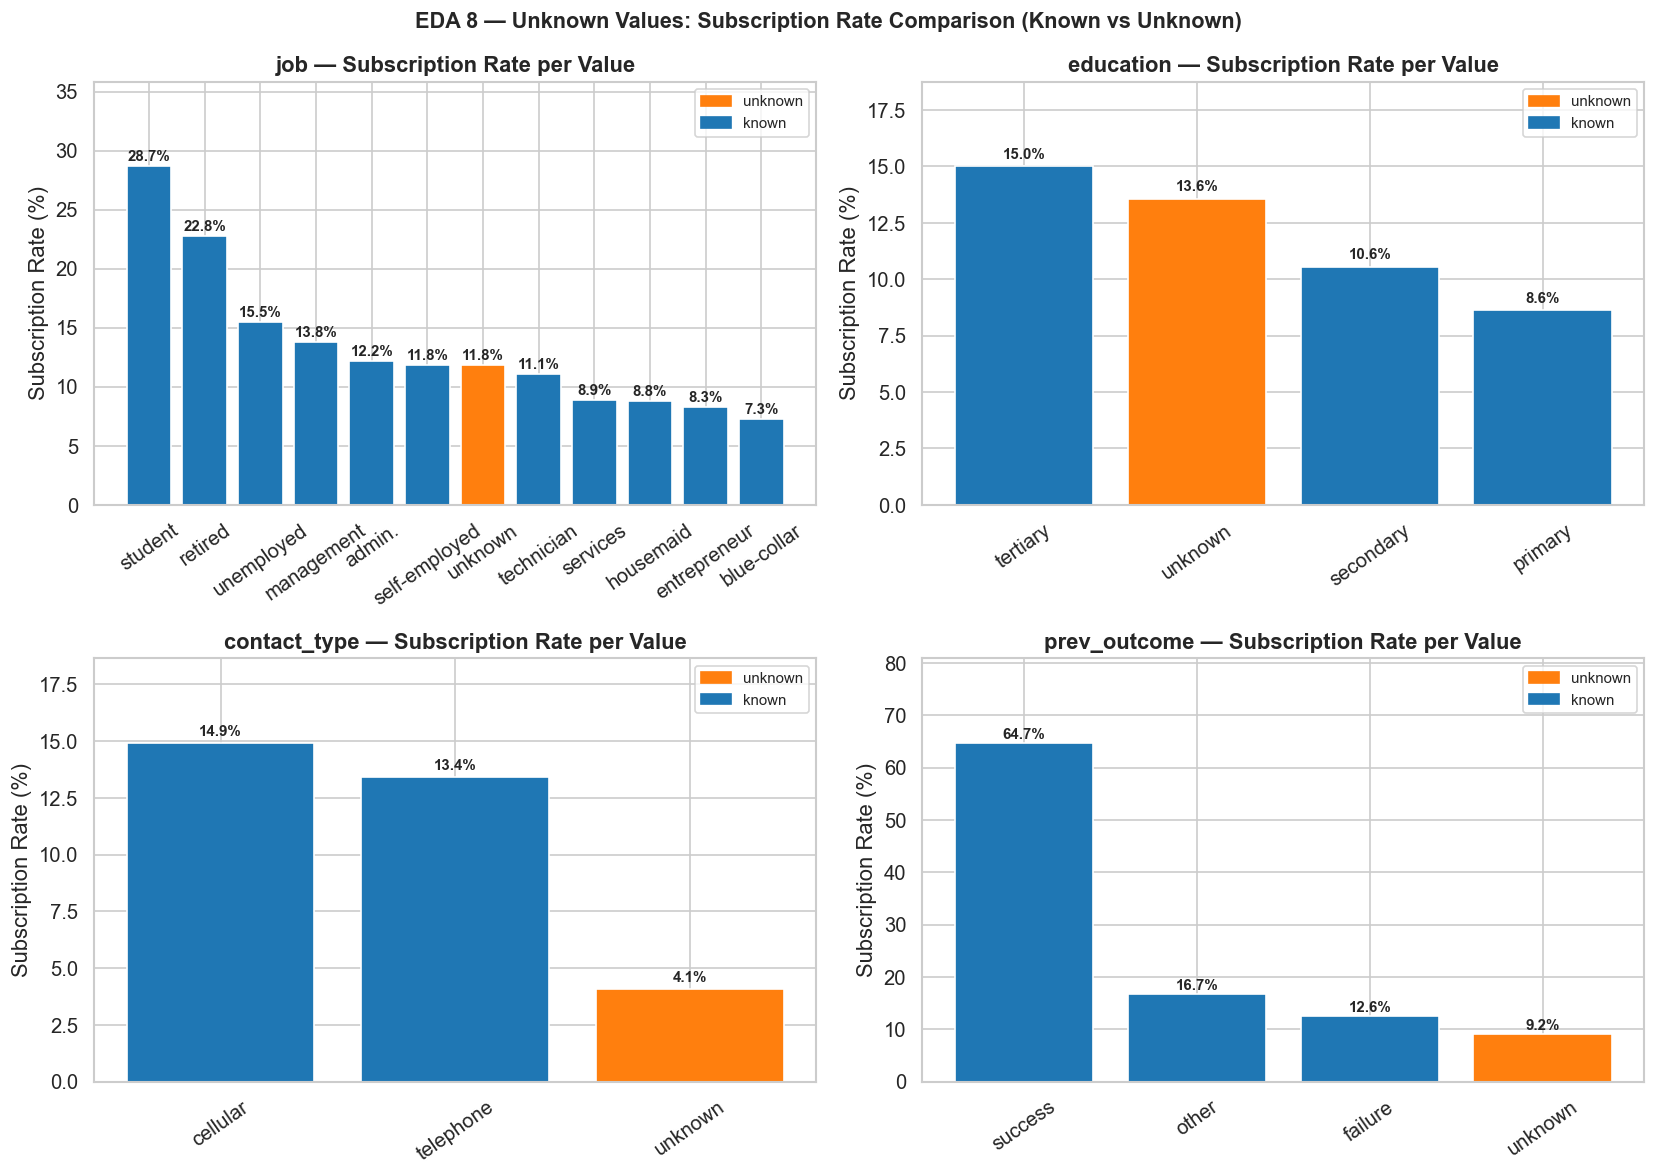


── Full Value Distribution per Column ──

JOB
               Count    Pct
job                        
blue-collar     9732  21.53
management      9458  20.92
technician      7597  16.80
admin.          5171  11.44
services        4154   9.19
retired         2264   5.01
self-employed   1579   3.49
entrepreneur    1487   3.29
unemployed      1303   2.88
housemaid       1240   2.74
student          938   2.07
unknown          288   0.64

EDUCATION
           Count    Pct
education              
secondary  23202  51.32
tertiary   13301  29.42
primary     6851  15.15
unknown     1857   4.11

CONTACT_TYPE
              Count    Pct
contact_type              
cellular      29285  64.77
unknown       13020  28.80
telephone      2906   6.43

PREV_OUTCOME
              Count    Pct
prev_outcome              
unknown       36959  81.75
failure        4901  10.84
other          1840   4.07
success        1511   3.34

📌 Key Decision Point: If 'unknown' rows have a meaningfully different
    subscr

In [11]:
# ── EDA 8: Unknown Value & Data Quality Analysis ────────────────────────────
cols_with_unknown = ['job', 'education', 'contact_type', 'prev_outcome']

# Unknown counts
print("=" * 60)
print(" UNKNOWN VALUE AUDIT")
print("=" * 60)
print(f"{'Column':<18} {'Unknown Count':>14} {'Unknown %':>12} {'Sub Rate (known)':>18} {'Sub Rate (unknown)':>20}")
print("-" * 86)
for col in cols_with_unknown:
    n_unk    = (df[col] == 'unknown').sum()
    pct_unk  = n_unk / len(df) * 100
    sub_known = df[df[col] != 'unknown']['y_bin'].mean() * 100
    sub_unk   = df[df[col] == 'unknown']['y_bin'].mean() * 100 if n_unk > 0 else float('nan')
    print(f"{col:<18} {n_unk:>14,} {pct_unk:>11.2f}% {sub_known:>17.2f}% {sub_unk:>19.2f}%")
print("=" * 86)

# Visual: subscription rate known vs unknown per column
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA 8 — Unknown Values: Subscription Rate Comparison (Known vs Unknown)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cols_with_unknown):
    sub_by_val = (df.groupby(col)['y_bin'].mean() * 100).sort_values(ascending=False)
    colors = ['#ff7f0e' if idx == 'unknown' else '#1f77b4' for idx in sub_by_val.index]
    bars = axes[i].bar(sub_by_val.index, sub_by_val.values, color=colors, edgecolor='white', linewidth=1)
    axes[i].set_title(f'{col} — Subscription Rate per Value', fontweight='bold')
    axes[i].set_ylabel('Subscription Rate (%)')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].set_ylim(0, sub_by_val.max() * 1.25)
    for bar, val in zip(bars, sub_by_val.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    # Legend
    from matplotlib.patches import Patch
    axes[i].legend(handles=[Patch(color='#ff7f0e', label='unknown'),
                             Patch(color='#1f77b4', label='known')], fontsize=9)

plt.tight_layout()
plt.show()

# Full value count audit
print("\n── Full Value Distribution per Column ──")
for col in cols_with_unknown:
    print(f"\n{col.upper()}")
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    out = pd.DataFrame({'Count': vc, 'Pct': pct.round(2)})
    print(out.to_string())

print("\n📌 Key Decision Point: If 'unknown' rows have a meaningfully different")
print("    subscription rate, they should be treated as a separate category,")
print("    not imputed or dropped.")